# Analyse exploratoire

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
DATA_PATH = "datas/"

app_train    = pd.read_csv(DATA_PATH + "application_train.csv")
bureau       = pd.read_csv(DATA_PATH + "bureau.csv")
bureau_bal   = pd.read_csv(DATA_PATH + "bureau_balance.csv")
prev_app     = pd.read_csv(DATA_PATH + "previous_application.csv")
pos_cash     = pd.read_csv(DATA_PATH + "POS_CASH_balance.csv")
install      = pd.read_csv(DATA_PATH + "installments_payments.csv")
cc_bal       = pd.read_csv(DATA_PATH + "credit_card_balance.csv")

files = {
    'application_train':    app_train,
    'bureau':               bureau,
    'bureau_balance':       bureau_bal,
    'previous_application': prev_app,
    'POS_CASH_balance':     pos_cash,
    'installments_payments':install,
    'credit_card_balance':  cc_bal,
}

print("=== Vue d'ensemble des fichiers ===\n")
for name, df in files.items():
    print(f"{name:<30} | {df.shape[0]:>10} lignes | {df.shape[1]:>3} colonnes")

=== Vue d'ensemble des fichiers ===

application_train              |     307511 lignes | 122 colonnes
bureau                         |    1716428 lignes |  17 colonnes
bureau_balance                 |   27299925 lignes |   3 colonnes
previous_application           |    1670214 lignes |  37 colonnes
POS_CASH_balance               |   10001358 lignes |   8 colonnes
installments_payments          |   13605401 lignes |   8 colonnes
credit_card_balance            |    3840312 lignes |  23 colonnes


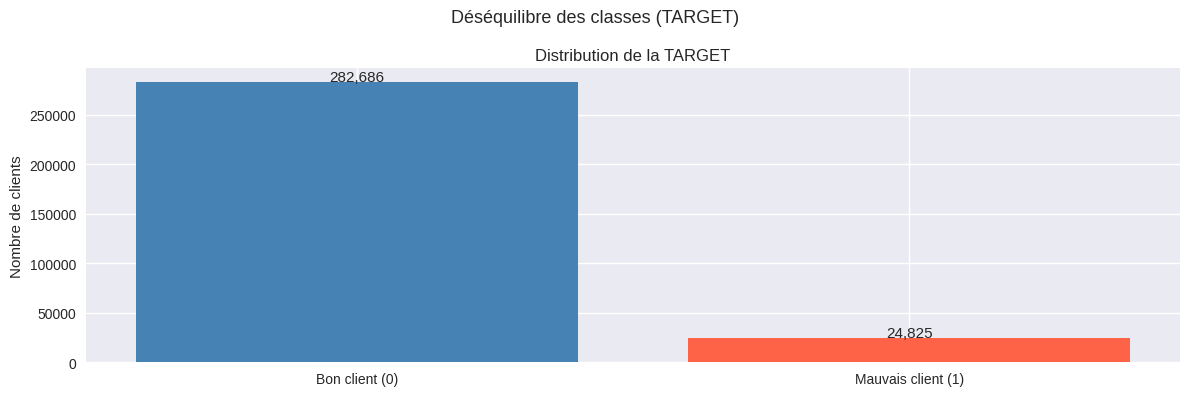

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

# Comptage absolu
counts = app_train['TARGET'].value_counts()
axes.bar(['Bon client (0)', 'Mauvais client (1)'],
            counts.values,
            color=['steelblue', 'tomato'])
axes.set_title("Distribution de la TARGET")
axes.set_ylabel("Nombre de clients")
for i, v in enumerate(counts.values):
    axes.text(i, v + 1000, f"{v:,}", ha='center', fontsize=11)

plt.suptitle("Déséquilibre des classes (TARGET)", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
print(app_train['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


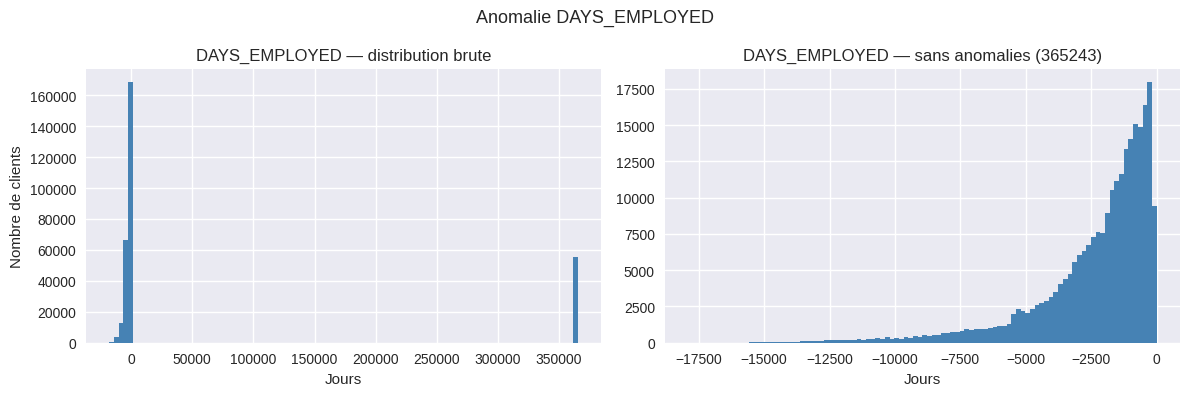

Nombre de clients avec DAYS_EMPLOYED = 365243 : 55,374 (18.0%)
Taux de défaut si DAYS_EMPLOYED = 365243 : 0.054
Taux de défaut si DAYS_EMPLOYED normal   : 0.087

→ La valeur 365243 correspond aux clients sans emploi enregistré.
→ Leur taux de défaut est plus faible, ce qui confirme que c'est une catégorie à part entière, pas une erreur à supprimer.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution brute de DAYS_EMPLOYED
axes[0].hist(app_train['DAYS_EMPLOYED'], bins=100, color='steelblue')
axes[0].set_title("DAYS_EMPLOYED distribution brute")
axes[0].set_xlabel("Jours")
axes[0].set_ylabel("Nombre de clients")

# Zoom sans les anomalies
clean = app_train[app_train['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED']
axes[1].hist(clean, bins=100, color='steelblue')
axes[1].set_title("DAYS_EMPLOYED sans anomalies (365243)")
axes[1].set_xlabel("Jours")

plt.suptitle("Anomalie DAYS_EMPLOYED", fontsize=13)
plt.tight_layout()
plt.show()

# Impact de l'anomalie sur le taux de défaut
n_anomalies = (app_train['DAYS_EMPLOYED'] == 365243).sum()
taux_defaut_anomalie = app_train.loc[
    app_train['DAYS_EMPLOYED'] == 365243, 'TARGET'].mean()
taux_defaut_normal = app_train.loc[
    app_train['DAYS_EMPLOYED'] != 365243, 'TARGET'].mean()

print(f"Nombre de clients avec DAYS_EMPLOYED = 365243 : {n_anomalies:,} "
      f"({n_anomalies/len(app_train)*100:.1f}%)")
print(f"Taux de défaut si DAYS_EMPLOYED = 365243 : {taux_defaut_anomalie:.3f}")
print(f"Taux de défaut si DAYS_EMPLOYED normal   : {taux_defaut_normal:.3f}")
print(f"\n→ La valeur 365243 correspond aux clients sans emploi enregistré.")
print(f"→ Leur taux de défaut est {'plus élevé' if taux_defaut_anomalie > taux_defaut_normal else 'plus faible'},"
      f" ce qui confirme que c'est une catégorie à part entière, pas une erreur à supprimer.")

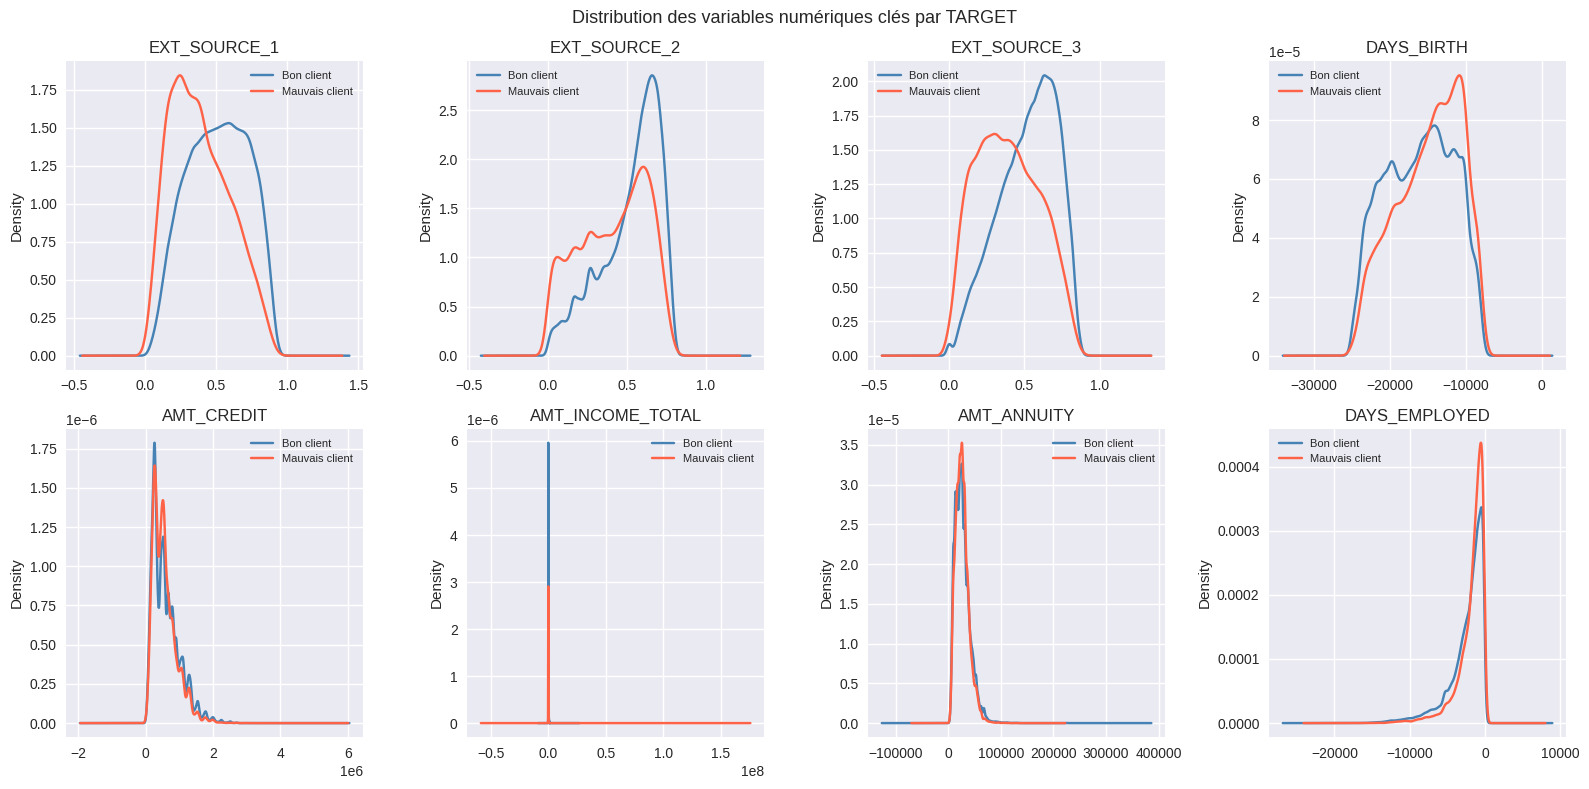

In [16]:
# On visualise les distributions des variables les plus corrélées à TARGET
# Un écart entre les deux courbes = pouvoir discriminant

num_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
    'AMT_ANNUITY', 'DAYS_EMPLOYED',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # On exclut les anomalies DAYS_EMPLOYED pour la visualisation
    data = app_train.copy()
    if col == 'DAYS_EMPLOYED':
        data = data[data['DAYS_EMPLOYED'] != 365243]

    for target, color, label in [(0, 'steelblue', 'Bon client'),
                                  (1, 'tomato', 'Mauvais client')]:
        subset = data.loc[data['TARGET'] == target, col].dropna()
        subset.plot.kde(ax=axes[i], label=label, color=color)

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution des variables numériques clés par TARGET", fontsize=13)
plt.tight_layout()
plt.show()

- EXT_SOURCE_1/2/3 : écart net entre les deux courbes — les mauvais clients sont concentrés sur les valeurs basses. Ce sont clairement les features les plus discriminantes. L'effet est particulièrement marqué sur EXT_SOURCE_2.
- DAYS_BIRTH : les mauvais clients sont plus jeunes (courbe rouge décalée vers la droite, donc moins de jours négatifs = moins âgés). L'âge est un signal réel. → Justifie la feature AGE_YEARS en feature engineering.
- AMT_CREDIT / AMT_ANNUITY : distributions quasi identiques entre bons et mauvais clients — ces variables brutes seules discriminent peu. C'est leur ratio qui sera utile (CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO). → Confirme l'intérêt des ratios du kernel jsaguiar.
- AMT_INCOME_TOTAL : courbes superposées, pas de signal seul. Utile uniquement en combinaison.
- DAYS_EMPLOYED : les courbes se superposent presque, sauf dans les valeurs récentes (proche de 0) où les mauvais clients sont légèrement surreprésentés. Signal faible seul.

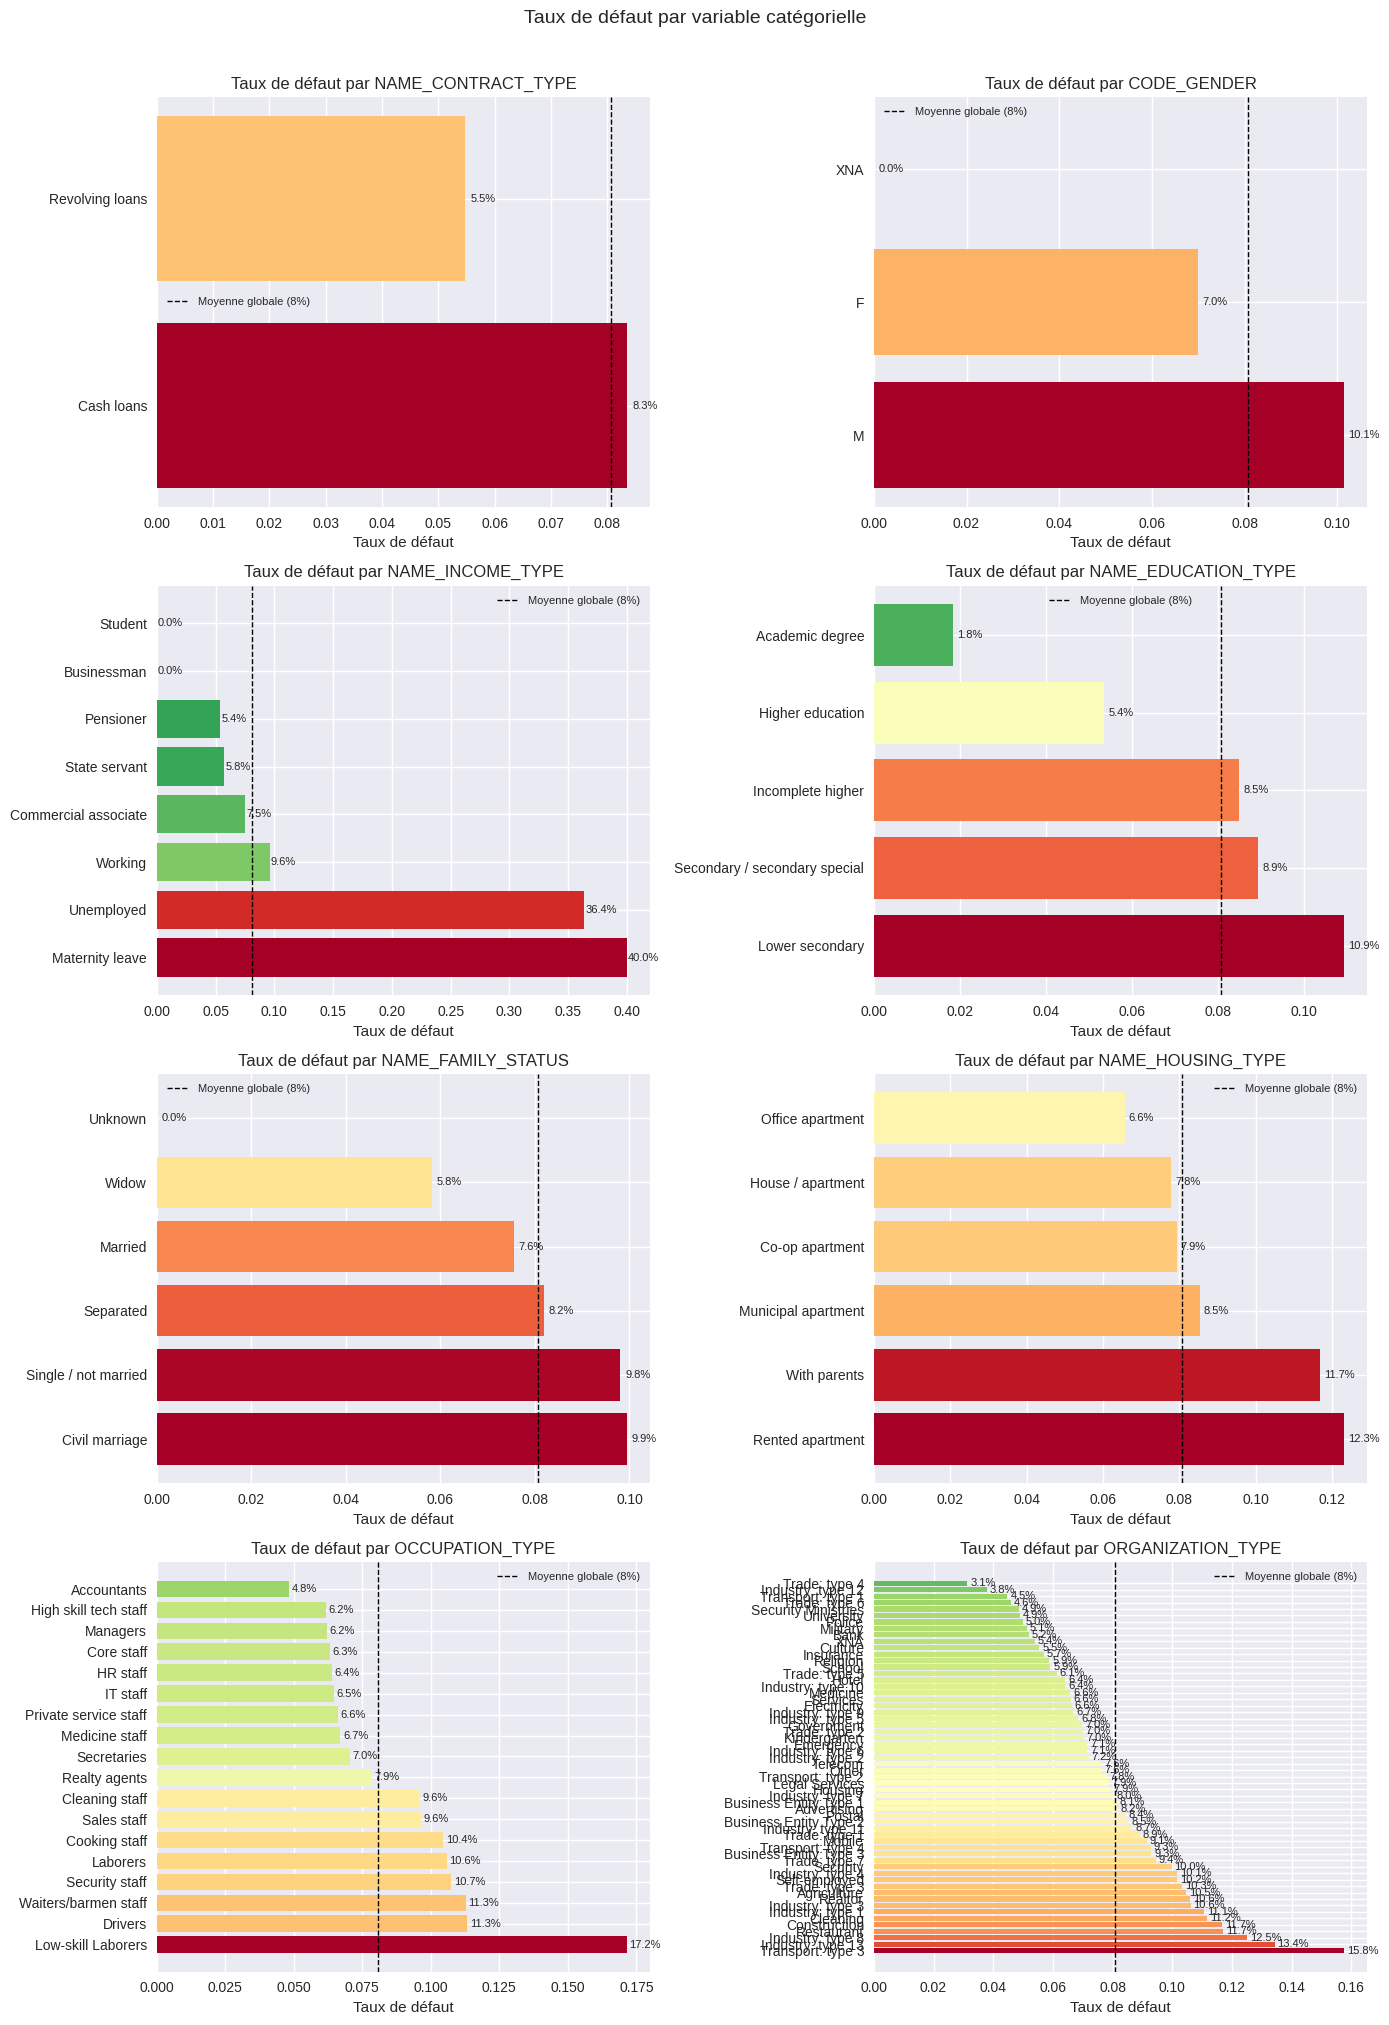

In [17]:
cat_features = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Taux de défaut par modalité, trié
    taux = app_train.groupby(col)['TARGET'].mean().sort_values(ascending=False)

    bars = axes[i].barh(taux.index, taux.values,
                        color=plt.cm.RdYlGn_r(taux.values / taux.max()))
    axes[i].axvline(app_train['TARGET'].mean(), color='black',
                    linestyle='--', linewidth=1, label='Moyenne globale (8%)')
    axes[i].set_title(f"Taux de défaut par {col}")
    axes[i].set_xlabel("Taux de défaut")
    axes[i].legend(fontsize=8)

    # Annotation des valeurs
    for bar, val in zip(bars, taux.values):
        axes[i].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center', fontsize=8)

plt.suptitle("Taux de défaut par variable catégorielle", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- NAME_CONTRACT_TYPE : Revolving loans défaut à 5.5% vs Cash loans à 8.3% — signal utile, variable à conserver.
- CODE_GENDER : Les hommes défaillent à 10.1% vs 7% pour les femmes. XNA à 0% (4 clients seulement) — jsaguiar les supprime, ce qu'on fera aussi. → Justifie de traiter XNA séparément.
- NAME_INCOME_TYPE : Maternity leave (40%) et Unemployed (36.4%) sont des signaux très forts, très au-dessus de la moyenne. Pensioners et State servants sont les plus fiables. → Justifie de créer des features groupées "profil à risque élevé".
- NAME_EDUCATION_TYPE : gradient parfait — plus le niveau d'éducation baisse, plus le taux de défaut monte. Academic degree à 1.8%, Lower secondary à 10.9%. → Variable très discriminante.
- NAME_FAMILY_STATUS : Civil marriage et Single les plus à risque. Widows les plus fiables après Unknown.
- NAME_HOUSING_TYPE : Rented apartment (12.3%) et With parents (11.7%) sont les plus risqués — logique, ce sont des profils moins stables.
- OCCUPATION_TYPE : Low-skill Laborers à 17.2% — presque le double de la moyenne. Accountants à 4.8% les plus fiables.
- ORGANIZATION_TYPE : Transport Type 3 à 15.8% et Industry Type 3 à 13.4% sont les plus risqués. → 58 modalités trop granulaires, regroupement nécessaire en feature engineering.

## *bureau.csv*

Clients avec historique bureau : 305,811 / 307,511 (99.4%)
Médiane crédits par client : 4
Max crédits pour un client : 116


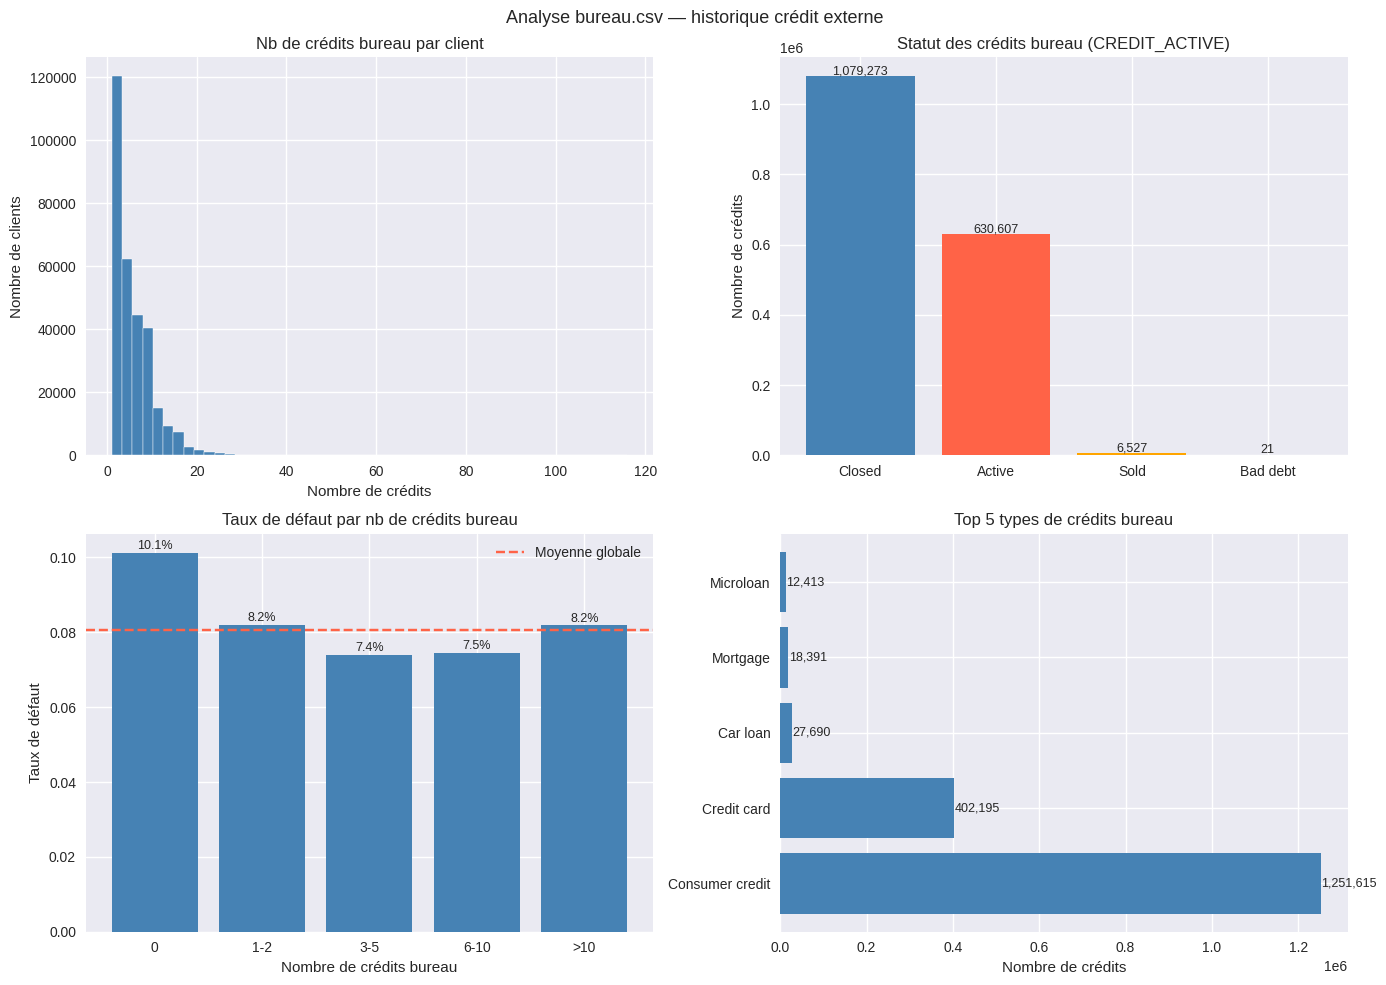

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution du nombre de crédits bureau par client
credits_per_client = bureau.groupby('SK_ID_CURR').size()
axes[0,0].hist(credits_per_client, bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title("Nb de crédits bureau par client")
axes[0,0].set_xlabel("Nombre de crédits")
axes[0,0].set_ylabel("Nombre de clients")
print(f"Clients avec historique bureau : {credits_per_client.shape[0]:,} "
      f"/ {app_train['SK_ID_CURR'].nunique():,} "
      f"({credits_per_client.shape[0]/app_train['SK_ID_CURR'].nunique()*100:.1f}%)")
print(f"Médiane crédits par client : {credits_per_client.median():.0f}")
print(f"Max crédits pour un client : {credits_per_client.max()}")

# 2. Distribution CREDIT_ACTIVE
credit_active_counts = bureau['CREDIT_ACTIVE'].value_counts()
axes[0,1].bar(credit_active_counts.index, credit_active_counts.values,
              color=['steelblue','tomato','orange','gray'])
axes[0,1].set_title("Statut des crédits bureau (CREDIT_ACTIVE)")
axes[0,1].set_ylabel("Nombre de crédits")
for i, v in enumerate(credit_active_counts.values):
    axes[0,1].text(i, v + 5000, f"{v:,}", ha='center', fontsize=9)

# 3. Taux de défaut selon nb de crédits bureau (découpage en quartiles)
bureau_count = bureau.groupby('SK_ID_CURR').size().reset_index(name='BUREAU_COUNT')
merged = app_train[['SK_ID_CURR','TARGET']].merge(bureau_count, on='SK_ID_CURR', how='left')
merged['BUREAU_COUNT'] = merged['BUREAU_COUNT'].fillna(0)
merged['BUREAU_COUNT_BIN'] = pd.cut(merged['BUREAU_COUNT'],
                                     bins=[-1,0,2,5,10,100],
                                     labels=['0','1-2','3-5','6-10','>10'])
taux_bureau = merged.groupby('BUREAU_COUNT_BIN', observed=True)['TARGET'].mean()
axes[1,0].bar(taux_bureau.index.astype(str), taux_bureau.values, color='steelblue')
axes[1,0].axhline(app_train['TARGET'].mean(), color='tomato',
                   linestyle='--', label='Moyenne globale')
axes[1,0].set_title("Taux de défaut par nb de crédits bureau")
axes[1,0].set_xlabel("Nombre de crédits bureau")
axes[1,0].set_ylabel("Taux de défaut")
axes[1,0].legend()
for i, v in enumerate(taux_bureau.values):
    axes[1,0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

# 4. Distribution CREDIT_TYPE (top 5)
top_types = bureau['CREDIT_TYPE'].value_counts().head(5)
axes[1,1].barh(top_types.index, top_types.values, color='steelblue')
axes[1,1].set_title("Top 5 types de crédits bureau")
axes[1,1].set_xlabel("Nombre de crédits")
for i, v in enumerate(top_types.values):
    axes[1,1].text(v + 1000, i, f"{v:,}", va='center', fontsize=9)

plt.suptitle("Analyse bureau.csv — historique crédit externe", fontsize=13)
plt.tight_layout()
plt.show()

- Nb de crédits par client : distribution très asymétrique, majorité des clients ont 1-5 crédits, quelques-uns jusqu'à 120. → Justifie d'utiliser log ou de borner les agrégations pour éviter que les outliers écrasent le signal.
- CREDIT_ACTIVE : 63% Closed, 37% Active. → Confirme qu'agréger séparément les crédits actifs et clôturés comme jsaguiar est pertinent — leur comportement est différent.
- Taux de défaut par nb de crédits : les clients sans historique bureau défaillent le plus (10.1%). Avoir des crédits clôturés est un signal positif (3-10 crédits = 7.4-7.5%). → Justifie le flag BUREAU_COUNT = 0 en feature engineering.
- Consumer credit domine à 73% des crédits — cohérent avec le profil de clientèle Home Credit (population peu bancarisée).

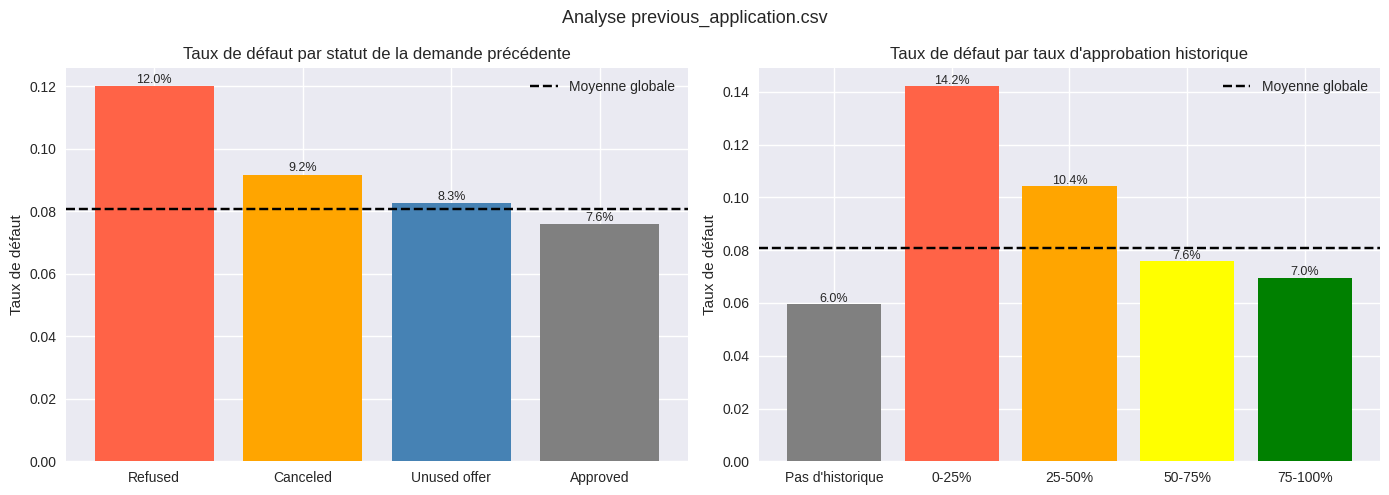

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Taux de défaut par statut de la demande précédente
prev_status = prev_app.merge(
    app_train[['SK_ID_CURR','TARGET']], on='SK_ID_CURR', how='left'
)
taux_status = prev_status.groupby('NAME_CONTRACT_STATUS')['TARGET'].mean().sort_values(ascending=False)
axes[0].bar(taux_status.index, taux_status.values,
            color=['tomato','orange','steelblue','gray'])
axes[0].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[0].set_title("Taux de défaut par statut de la demande précédente")
axes[0].set_ylabel("Taux de défaut")
axes[0].legend()
for i, v in enumerate(taux_status.values):
    axes[0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

# 2. Taux de défaut par taux d'approbation historique
prev_approval = prev_app.groupby('SK_ID_CURR').apply(
    lambda x: (x['NAME_CONTRACT_STATUS'] == 'Approved').mean()
).reset_index(name='APPROVAL_RATE')
appr_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    prev_approval, on='SK_ID_CURR', how='left'
)
appr_merged['APPR_BIN'] = pd.cut(
    appr_merged['APPROVAL_RATE'].fillna(-1),
    bins=[-2, -0.5, 0.25, 0.5, 0.75, 1.01],
    labels=["Pas d'historique", '0-25%', '25-50%', '50-75%', '75-100%']
)
taux_appr = appr_merged.groupby('APPR_BIN', observed=True)['TARGET'].mean()
axes[1].bar(taux_appr.index.astype(str), taux_appr.values,
            color=['gray','tomato','orange','yellow','green'])
axes[1].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[1].set_title("Taux de défaut par taux d'approbation historique")
axes[1].set_ylabel("Taux de défaut")
axes[1].legend()
for i, v in enumerate(taux_appr.values):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle("Analyse previous_application.csv", fontsize=13)
plt.tight_layout()
plt.show()

- Statut demande précédente : les clients dont les demandes avaient été Refused défaillent à 12% — 50% au-dessus de la moyenne. Les Approved sont les plus fiables à 7.6%. → Confirme qu'agréger séparément Approved et Refused comme jsaguiar est pertinent.
- Taux d'approbation historique : relation non-linéaire intéressante. Les clients avec 0-25% d'approbation sont les plus risqués (14.2%) — logique, la banque les avait déjà jugés risqués. Mais les clients sans historique sont à 6% — ils sont nouveaux, pas mauvais. → Le flag "pas d'historique" est une feature à part entière, à ne pas mélanger avec les autres bins.

In [22]:
bureau_bal.columns

Index(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS', 'IS_DPD'], dtype='object')

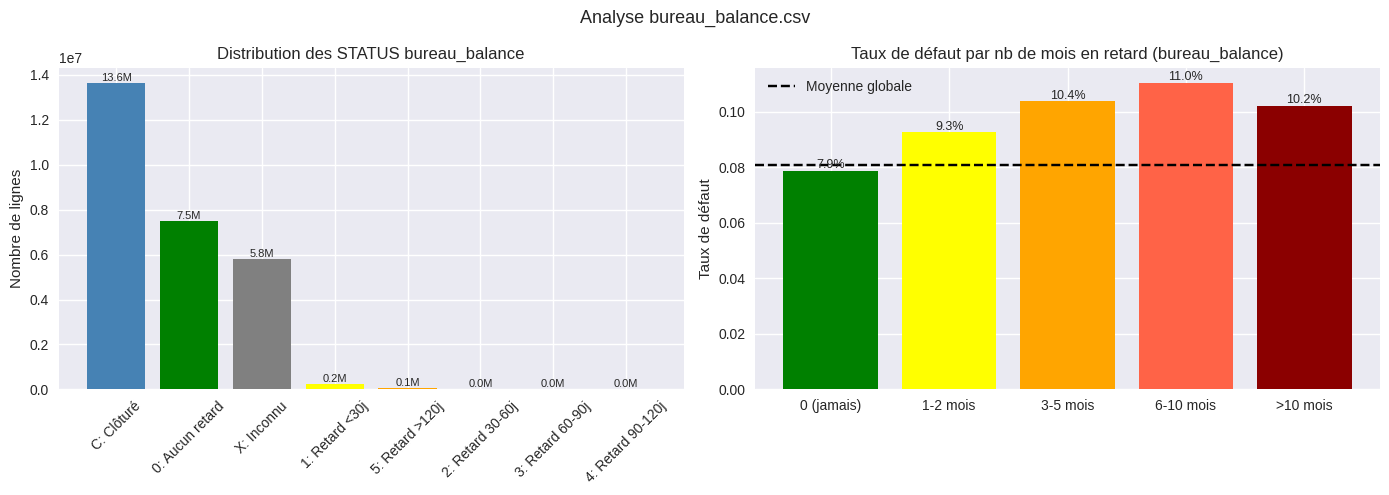

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution des STATUS
status_counts = bureau_bal['STATUS'].value_counts()
status_labels = {
    'C': 'C: Clôturé',
    '0': '0: Aucun retard',
    'X': 'X: Inconnu',
    '1': '1: Retard <30j',
    '2': '2: Retard 30-60j',
    '3': '3: Retard 60-90j',
    '4': '4: Retard 90-120j',
    '5': '5: Retard >120j',
}
colors = ['steelblue','green','gray','yellow','orange','darkorange','red','darkred']
labels = [status_labels.get(s, s) for s in status_counts.index]
axes[0].bar(labels, status_counts.values, color=colors)
axes[0].set_title("Distribution des STATUS bureau_balance")
axes[0].set_ylabel("Nombre de lignes")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 100000, f"{v/1e6:.1f}M", ha='center', fontsize=8)

# 2. Taux de défaut selon nb de mois avec retard
# bureau_balance n'a pas SK_ID_CURR → on passe par bureau pour le lien
bureau_bal['IS_DPD'] = bureau_bal['STATUS'].isin(['1','2','3','4','5']).astype(int)

# Nb de mois en retard par SK_ID_BUREAU
dpd_by_bureau = bureau_bal.groupby('SK_ID_BUREAU')['IS_DPD'].sum().reset_index(name='DPD_MONTHS')

# Lien SK_ID_BUREAU → SK_ID_CURR via bureau
bureau_ids = bureau[['SK_ID_BUREAU','SK_ID_CURR']].drop_duplicates()
dpd_by_bureau = dpd_by_bureau.merge(bureau_ids, on='SK_ID_BUREAU', how='left')

# Somme des mois en retard par client
dpd_by_client = dpd_by_bureau.groupby('SK_ID_CURR')['DPD_MONTHS'].sum().reset_index()

dpd_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    dpd_by_client, on='SK_ID_CURR', how='left'
)
dpd_merged['DPD_MONTHS'] = dpd_merged['DPD_MONTHS'].fillna(0)
dpd_merged['DPD_BIN'] = pd.cut(
    dpd_merged['DPD_MONTHS'],
    bins=[-1, 0, 2, 5, 10, 10000],
    labels=['0 (jamais)', '1-2 mois', '3-5 mois', '6-10 mois', '>10 mois']
)
taux_dpd = dpd_merged.groupby('DPD_BIN', observed=True)['TARGET'].mean()
axes[1].bar(taux_dpd.index.astype(str), taux_dpd.values,
            color=['green','yellow','orange','tomato','darkred'])
axes[1].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[1].set_title("Taux de défaut par nb de mois en retard (bureau_balance)")
axes[1].set_ylabel("Taux de défaut")
axes[1].legend()
for i, v in enumerate(taux_dpd.values):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle("Analyse bureau_balance.csv", fontsize=13)
plt.tight_layout()
plt.show()

- Distribution STATUS : l'immense majorité est C (clôturé) et 0 (aucun retard) — les retards réels (1-5) sont rares mais existent. Les STATUS X (inconnu) représentent 5.8M de lignes — à ne pas confondre avec un retard.
- Taux de défaut par mois en retard : gradient clair et monotone jusqu'à 6-10 mois (11%), puis légère baisse à >10 mois (10.2%) — probablement des clients avec un très long historique dont certains se sont stabilisés. Le signal est là : chaque mois de retard supplémentaire augmente le risque. → Confirme que BB_DPD_COUNT_TOTAL est une feature pertinente.

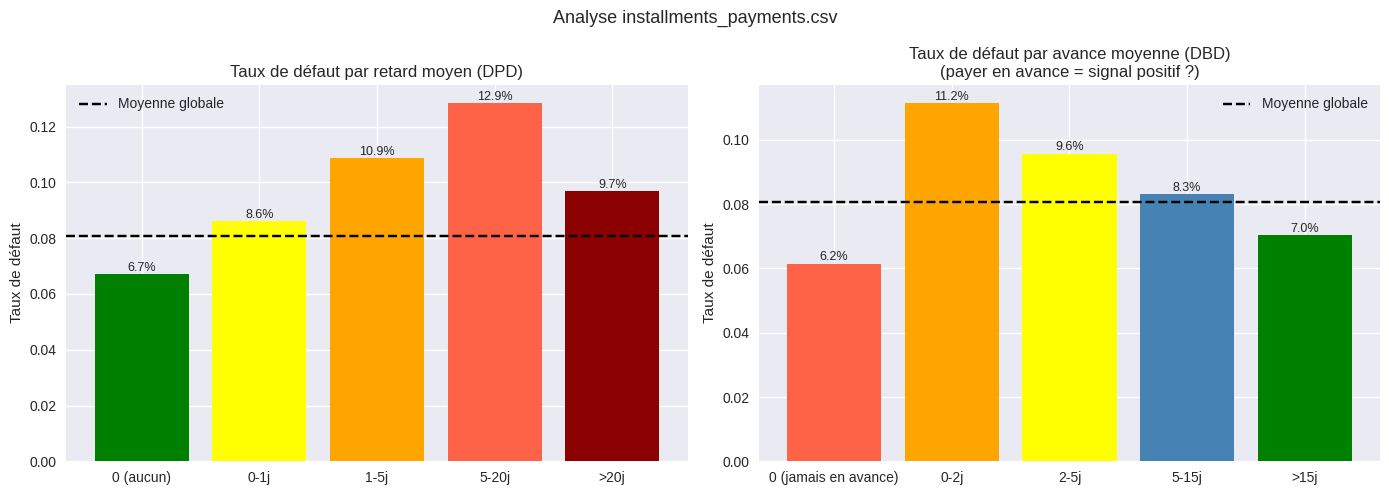

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature dérivée : retard de paiement (positif = en retard)
install['DPD'] = (install['DAYS_ENTRY_PAYMENT'] - install['DAYS_INSTALMENT']).clip(lower=0)
install['DBD'] = (install['DAYS_INSTALMENT'] - install['DAYS_ENTRY_PAYMENT']).clip(lower=0)

# 1. Taux de défaut par retard moyen sur les paiements
dpd_client = install.groupby('SK_ID_CURR')['DPD'].mean().reset_index(name='DPD_MEAN')
dpd_merged = app_train[['SK_ID_CURR','TARGET']].merge(dpd_client, on='SK_ID_CURR', how='left')
dpd_merged['DPD_BIN'] = pd.cut(
    dpd_merged['DPD_MEAN'].fillna(0),
    bins=[-1, 0, 1, 5, 20, 10000],
    labels=['0 (aucun)', '0-1j', '1-5j', '5-20j', '>20j']
)
taux_dpd = dpd_merged.groupby('DPD_BIN', observed=True)['TARGET'].mean()
axes[0].bar(taux_dpd.index.astype(str), taux_dpd.values,
            color=['green','yellow','orange','tomato','darkred'])
axes[0].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[0].set_title("Taux de défaut par retard moyen (DPD)")
axes[0].set_ylabel("Taux de défaut")
axes[0].legend()
for i, v in enumerate(taux_dpd.values):
    axes[0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

# 2. Taux de défaut par avance moyenne sur les paiements
dbd_client = install.groupby('SK_ID_CURR')['DBD'].mean().reset_index(name='DBD_MEAN')
dbd_merged = app_train[['SK_ID_CURR','TARGET']].merge(dbd_client, on='SK_ID_CURR', how='left')
dbd_merged['DBD_BIN'] = pd.cut(
    dbd_merged['DBD_MEAN'].fillna(0),
    bins=[-1, 0, 2, 5, 15, 10000],
    labels=['0 (jamais en avance)', '0-2j', '2-5j', '5-15j', '>15j']
)
taux_dbd = dbd_merged.groupby('DBD_BIN', observed=True)['TARGET'].mean()
axes[1].bar(taux_dbd.index.astype(str), taux_dbd.values,
            color=['tomato','orange','yellow','steelblue','green'])
axes[1].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[1].set_title("Taux de défaut par avance moyenne (DBD)\n(payer en avance = signal positif ?)")
axes[1].set_ylabel("Taux de défaut")
axes[1].legend()
for i, v in enumerate(taux_dbd.values):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle("Analyse installments_payments.csv", fontsize=13)
plt.tight_layout()
plt.show()

- DPD (retard) : gradient clair — plus le retard moyen augmente, plus le risque monte, jusqu'à 5-20j (12.9%). La légère baisse à >20j (9.7%) s'explique probablement par des clients avec un très long historique qui se sont stabilisés. → DPD est une feature solide à conserver.
- DBD (avance) — résultat contre-intuitif : les clients qui ne paient jamais en avance (0j) sont les plus fiables (6.2%). Ceux qui paient 0-2j en avance sont les plus risqués (11.2%), puis le risque diminue à mesure que l'avance augmente. Payer légèrement en avance n'est donc pas un signal positif — c'est peut-être un comportement erratique. Payer franchement en avance (>15j) est en revanche un bon signal (7%). → DBD mérite d'être gardé mais son interprétation est subtile.

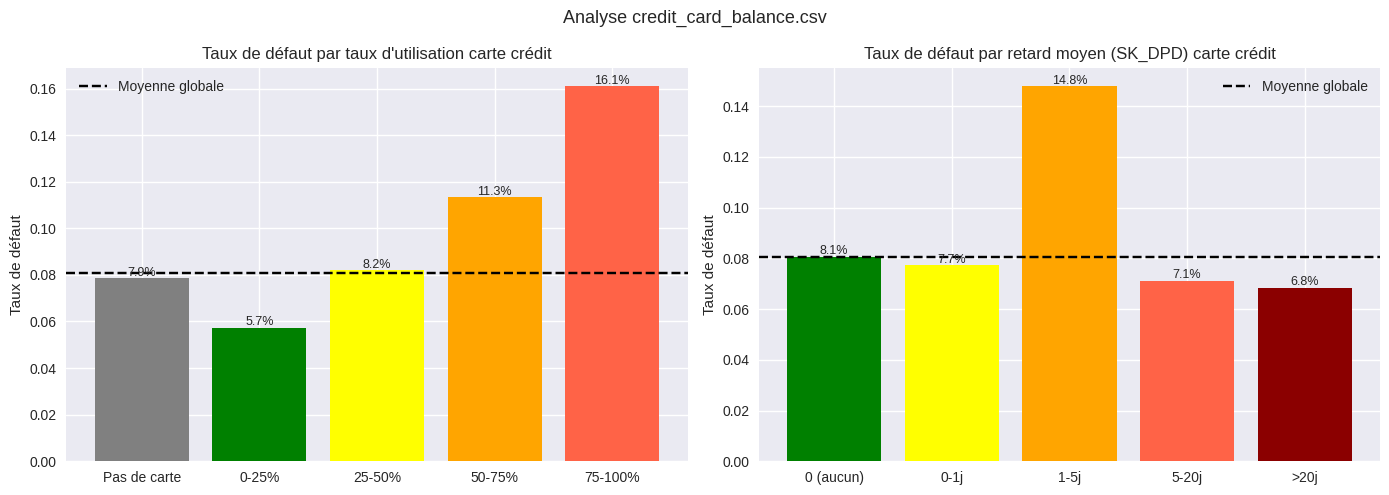

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Taux de défaut par taux d'utilisation moyen de la carte
cc_bal['UTILIZATION'] = (
    cc_bal['AMT_BALANCE'] /
    cc_bal['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
).clip(0, 1)

util_client = cc_bal.groupby('SK_ID_CURR')['UTILIZATION'].mean().reset_index(name='UTIL_MEAN')
util_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    util_client, on='SK_ID_CURR', how='left'
)
util_merged['UTIL_BIN'] = pd.cut(
    util_merged['UTIL_MEAN'].fillna(-1),
    bins=[-2, -0.5, 0.25, 0.5, 0.75, 1.01],
    labels=['Pas de carte', '0-25%', '25-50%', '50-75%', '75-100%']
)
taux_util = util_merged.groupby('UTIL_BIN', observed=True)['TARGET'].mean()
axes[0].bar(taux_util.index.astype(str), taux_util.values,
            color=['gray','green','yellow','orange','tomato'])
axes[0].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[0].set_title("Taux de défaut par taux d'utilisation carte crédit")
axes[0].set_ylabel("Taux de défaut")
axes[0].legend()
for i, v in enumerate(taux_util.values):
    axes[0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

# 2. Taux de défaut par retard moyen sur carte de crédit
dpd_cc = cc_bal.groupby('SK_ID_CURR')['SK_DPD'].mean().reset_index(name='CC_DPD_MEAN')
dpd_cc_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    dpd_cc, on='SK_ID_CURR', how='left'
)
dpd_cc_merged['DPD_BIN'] = pd.cut(
    dpd_cc_merged['CC_DPD_MEAN'].fillna(0),
    bins=[-1, 0, 1, 5, 20, 10000],
    labels=['0 (aucun)', '0-1j', '1-5j', '5-20j', '>20j']
)
taux_dpd_cc = dpd_cc_merged.groupby('DPD_BIN', observed=True)['TARGET'].mean()
axes[1].bar(taux_dpd_cc.index.astype(str), taux_dpd_cc.values,
            color=['green','yellow','orange','tomato','darkred'])
axes[1].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[1].set_title("Taux de défaut par retard moyen (SK_DPD) carte crédit")
axes[1].set_ylabel("Taux de défaut")
axes[1].legend()
for i, v in enumerate(taux_dpd_cc.values):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle("Analyse credit_card_balance.csv", fontsize=13)
plt.tight_layout()
plt.show()

- Taux d'utilisation : gradient parfait et très fort — 75-100% d'utilisation = 16.1% de défaut, soit le double de la moyenne. Avoir une carte peu utilisée (0-25%) est au contraire très protecteur (5.7%). → CC_UTILIZATION est l'une des features les plus puissantes du dataset.
- SK_DPD carte : résultat contre-intuitif similaire au DBD — les retards modérés (1-5j) sont les plus risqués (14.8%), mais les très longs retards (>20j) descendent à 6.8%. Les clients avec >20j de retard sont probablement en restructuration active, donc "gérés". C'est le retard intermédiaire qui échappe aux radars.

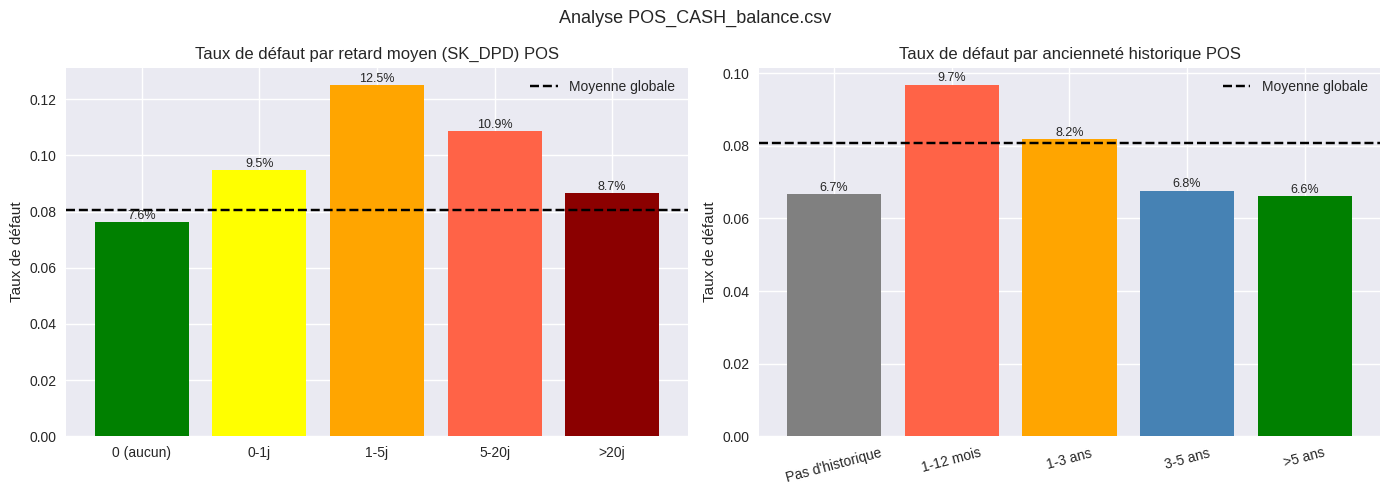

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Taux de défaut par retard moyen POS
dpd_pos = pos_cash.groupby('SK_ID_CURR')['SK_DPD'].mean().reset_index(name='POS_DPD_MEAN')
dpd_pos_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    dpd_pos, on='SK_ID_CURR', how='left'
)
dpd_pos_merged['DPD_BIN'] = pd.cut(
    dpd_pos_merged['POS_DPD_MEAN'].fillna(0),
    bins=[-1, 0, 1, 5, 20, 10000],
    labels=['0 (aucun)', '0-1j', '1-5j', '5-20j', '>20j']
)
taux_dpd_pos = dpd_pos_merged.groupby('DPD_BIN', observed=True)['TARGET'].mean()
axes[0].bar(taux_dpd_pos.index.astype(str), taux_dpd_pos.values,
            color=['green','yellow','orange','tomato','darkred'])
axes[0].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[0].set_title("Taux de défaut par retard moyen (SK_DPD) POS")
axes[0].set_ylabel("Taux de défaut")
axes[0].legend()
for i, v in enumerate(taux_dpd_pos.values):
    axes[0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

# 2. Taux de défaut selon nb de mois d'historique POS
pos_count = pos_cash.groupby('SK_ID_CURR').size().reset_index(name='POS_COUNT')
pos_merged = app_train[['SK_ID_CURR','TARGET']].merge(
    pos_count, on='SK_ID_CURR', how='left'
)
pos_merged['POS_COUNT'] = pos_merged['POS_COUNT'].fillna(0)
pos_merged['COUNT_BIN'] = pd.cut(
    pos_merged['POS_COUNT'],
    bins=[-1, 0, 12, 36, 60, 100000],
    labels=['Pas d\'historique', '1-12 mois', '1-3 ans', '3-5 ans', '>5 ans']
)
taux_pos_count = pos_merged.groupby('COUNT_BIN', observed=True)['TARGET'].mean()
axes[1].bar(taux_pos_count.index.astype(str), taux_pos_count.values,
            color=['gray','tomato','orange','steelblue','green'])
axes[1].axhline(app_train['TARGET'].mean(), color='black',
                linestyle='--', label='Moyenne globale')
axes[1].set_title("Taux de défaut par ancienneté historique POS")
axes[1].set_ylabel("Taux de défaut")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(taux_pos_count.values):
    axes[1].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle("Analyse POS_CASH_balance.csv", fontsize=13)
plt.tight_layout()
plt.show()

- DPD : même pattern que installments — 1-5j est le plus risqué (12.5%), puis le risque redescend pour les très longs retards. Signal cohérent et exploitable.
- Ancienneté POS : les clients avec 1-12 mois d'historique sont les plus risqués (9.7%) — ce sont des nouveaux clients dont on ne connaît pas encore le comportement stable. Au-delà de 3 ans d'historique, le risque descend sous la moyenne et reste stable. Les clients sans historique POS sont à 6.7% — ils n'ont simplement jamais eu de crédit POS chez Home Credit, ce n'est pas un signal négatif.

## Synthèse de l'analyse exploratoire

### Ce qu'on a appris sur les clients à risque

Les mauvais clients (TARGET=1) représentent 8% du portefeuille, soit 1 pour 11 bons clients. Ce déséquilibre est modéré mais suffisant pour biaiser un modèle naïf — le `class_weight='balanced'` sera indispensable.

### Les signaux les plus forts

**EXT_SOURCE_1, 2 et 3** sont de loin les variables les plus discriminantes. Les mauvais clients sont massivement concentrés sur les valeurs basses. On ne sait pas exactement ce qu'elles mesurent (scores externes), mais elles seront au cœur du modèle.

**L'âge** joue un rôle clair : les jeunes clients défaillent davantage. À convertir en années (AGE_YEARS) pour plus de lisibilité.

**L'éducation** suit un gradient parfait : Academic degree à 1.8% de défaut, Lower secondary à 10.9%. Variable très utile.

**Le type de profession** est très discriminant : Maternity leave (40%) et Unemployed (36.4%) sont des signaux d'alarme forts. À l'inverse, Accountants (4.8%) et Pensioners (5.4%) sont les profils les plus fiables.

**Le logement** : louer ou vivre chez ses parents sont des signaux de précarité (11-12% de défaut vs 8% en moyenne).

### Les signaux comportementaux (tables secondaires)

Le comportement passé est prédictif, mais de façon non-linéaire :

- **Retard de paiement (DPD)** : signal fort et monotone sur installments et POS. 1-5j de retard moyen = profil très risqué.
- **Utilisation carte crédit** : gradient parfait. 75-100% d'utilisation = 16.1% de défaut (double de la moyenne). C'est l'une des features comportementales les plus puissantes.
- **Taux d'approbation historique** : avoir été souvent refusé par le passé (0-25% d'approbation) = 14.2% de défaut.
- **Mois de retard bureau** : signal monotone confirmé. Plus de mois en retard = plus de risque.

### Anomalie DAYS_EMPLOYED

La valeur 365243 (≈1000 ans) est une valeur sentinelle codant "sans emploi enregistré". Ces 18% de clients ont un taux de défaut de 5.4% — inférieur à la moyenne (8.7%). Ce sont probablement des retraités ou indépendants. **Cette information doit être capturée par un flag binaire avant imputation.**

### Ce qu'on fera différemment en feature engineering

- Créer `DAYS_EMPLOYED_ANOMALY` avant de remplacer 365243 par NaN
- Agréger bureau séparément pour les crédits Actifs et Clôturés
- Agréger previous_application séparément pour Approved et Refused
- Ajouter `DBD` (days before due) sur installments
- Ajouter `PAYMENT_PERC` = AMT_PAYMENT / AMT_INSTALMENT
- Ajouter `INCOME_PER_PERSON` et `PAYMENT_RATE`
- Créer des flags pour absence d'historique bureau et POS